# 🚗 Projeto de Análise de Carros Elétricos


### 📌 Introdução

    Com o crescimento da indústria de veículos elétricos, vejo como algo interessante analisar os dados de modelos, autonomia e tendências de mercado. Na busca de trazer conclusões sobre o assunto, trago análises estatísticas sobre o uso de carros elétricos no estado de Washignton (EUA) entre os anos 2000-2025.

<p align="center">
  <img src="https://f.i.uol.com.br/fotografia/2023/05/26/168512996364710aebd8ee8_1685129963_3x2_md.jpg" width="700">
</p>

#### 📂 Carregando os Dados
Nesta etapa, faremos as configurações dos parâmetros básicos para a análise.

In [ ]:
# =========================================
# 1) Imports e configuração global
# =========================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')
# ==========================================
# 2) Padronização dos gráficos
# ==========================================
sns.set_style('white')
plt.figure(figsize = (10, 6))

# ========================================
# 3) Configuração de funções
# ========================================
def carregar_dados (arquivo: str) -> pd.DataFrame:
    df = pd.read_csv('Electric_Vehicle_Population_Data.csv')
    return df

def limpar_renomear (df : pd.DataFrame) -> pd.DataFrame:

    dropar_colunas = ['Postal Code','Legislative District','DOL Vehicle ID','Vehicle Location','2020 Census Tract']

    manter = [x for x in df.columns if x not in dropar_colunas]

    df = df[manter].copy()

    df.columns = df.columns.str.lower()

    colunas_traduzidas = { 'vin (1-10)' : 'placa',
                       'county': 'condado',
                       'city': 'cidade',
                       'state':'estado',
                       'model year':'ano_modelo',
                       'make':'montadora',
                       'model':'modelo',
                       'electric vehicle type':'tipo_veiculo_eletrico',
                       'clean alternative fuel vehicle (cafv) eligibility':'elegibilidade_combustivel_alternativo_limpo',
                       'electric utility':'concessionaria_eletrica',
                       'electric range':'alcance_elétrico'}
    df  = df.rename(columns=colunas_traduzidas)

    df.columns = (
    df.columns
    .str.strip()                             # Remove espaços nas bordas
    .str.lower()                             # Converte para minúsculas
    .str.replace(' ', '_')                   # Substitui espaços por underscores
    .str.replace('-', '_')                   # Substitui hífens por underscores
    .str.replace(r'[^\w_]', '', regex=True)  # Remove parênteses, barras e outros símbolos
    )

    return df
df = carregar_dados('Electric_Vehicle_Population_Data.csv')
df = limpar_renomear(df)

<Figure size 1000x600 with 0 Axes>

### 📝 Análise Geral

Para iniciar análise, optei por trazer a quantidade de veículos por tipo: se híbrido (funciona a bateria e combustível fóssil) ou se totalmente elétrico. Nesse gráfico, foi perceptível que a grande maioria dos veículos da base são totalmente elétricos.

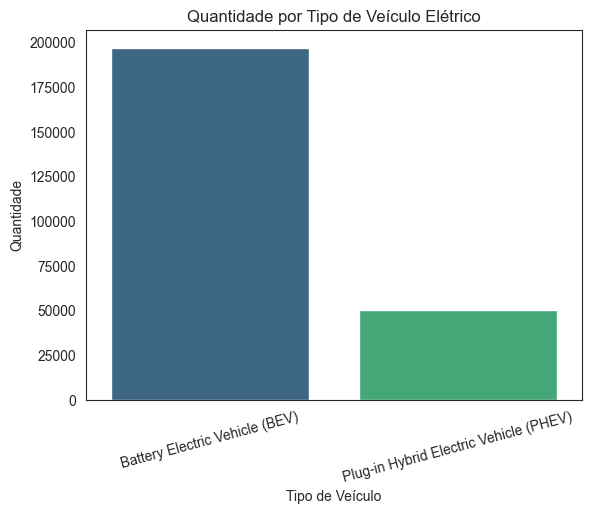

In [23]:
plt.figure()
sns.countplot(
    data=df, 
    x='tipo_veiculo_eletrico', 
    palette="viridis",
    order=df["tipo_veiculo_eletrico"].value_counts().index
)
plt.title("Quantidade por Tipo de Veículo Elétrico")
plt.xlabel("Tipo de Veículo")
plt.ylabel("Quantidade")
plt.xticks(rotation=15)
plt.show()

A seguir optei por um histograma para trazer a quantidade de veículos por ano de fabricação, evidenciando duas crescentes: nos anos entre 2015 e 2020 e uma ainda maior entre 2020 e 2025.

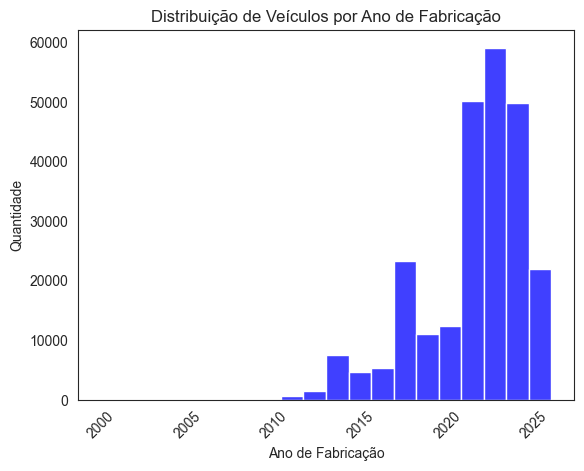

In [25]:
plt.figure()
sns.histplot(df['ano_modelo'], bins = 20, kde= False, color = 'blue')
plt.title("Distribuição de Veículos por Ano de Fabricação",fontsize = 12)
plt.xlabel("Ano de Fabricação", fontsize = 10)
plt.ylabel("Quantidade", fontsize = 10)
plt.xticks(rotation=45)
plt.show()

Ao realizar um top 10 das montadoras com mais vendas de carro, foi possível concluir a grande vantagem que a TESLA possui sobre as demais
com cerca de 100.000 unidades vendidas ao longo dos 20 anos.

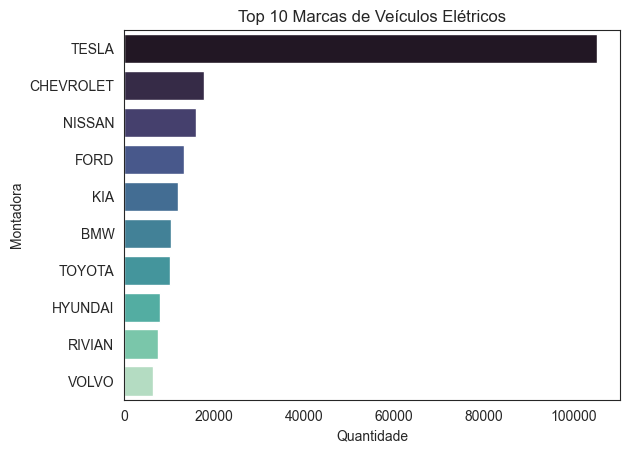

In [27]:
top_montadoras = df["montadora"].value_counts().head(10)
plt.figure()
sns.barplot(x=top_montadoras.values, y=top_montadoras.index, palette="mako")
plt.title("Top 10 Marcas de Veículos Elétricos")
plt.xlabel("Quantidade")
plt.ylabel("Montadora")
plt.show()

No entanto, apesar da liderança nas vendas, a TESLA não possui a melhor autonomia elétrica das suas baterias,
sendo superada pela média das montadoras como: Jaguar, Wheego Electric Cars, Th!nk, ficando apenas em 8° lugar.

Text(0, 0.5, 'Montadora')

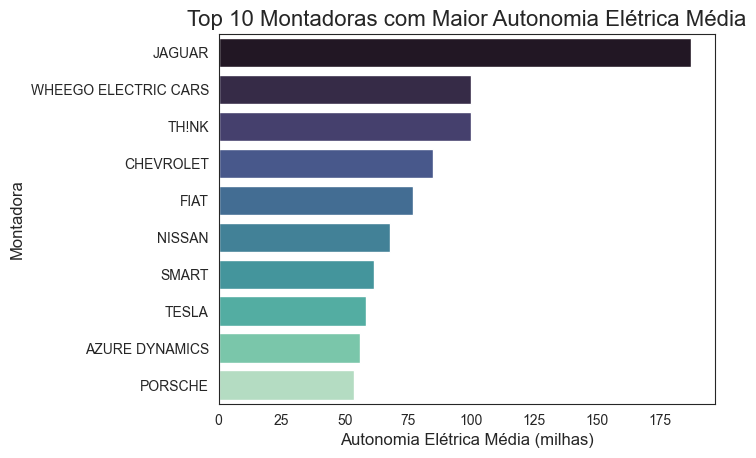

In [ ]:
df_top10 = df.groupby('montadora')['alcance_elétrico'].mean()
df_top10 = df_top10.sort_values(ascending=False).head(10)
df_top10 = df_top10.reset_index()

plt.figure()
sns.barplot(x="alcance_elétrico", y="montadora", data=df_top10, palette="mako")
plt.title("Top 10 Montadoras com Maior Autonomia Elétrica Média", fontsize=16)
plt.xlabel("Autonomia Elétrica Média (milhas)", fontsize=12)
plt.ylabel("Montadora", fontsize=12)

Indo mais a fundo sobre a autonomia elétrica dos carros, decidi verificá-las a partir da quantidade de veículos e me surpreendi ao perceber que a grande maioria não percorria distância alguma ou pouquíssima se ligado a bateria.

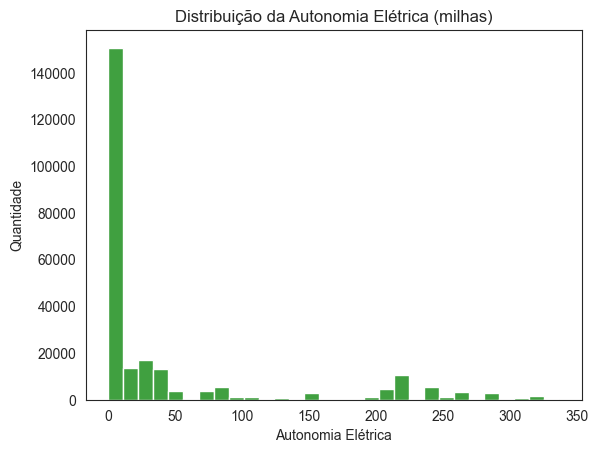

In [31]:
plt.figure()
sns.histplot(df["alcance_elétrico"], bins=30, kde=False, color="green")
plt.title("Distribuição da Autonomia Elétrica (milhas)")
plt.xlabel("Autonomia Elétrica")
plt.ylabel("Quantidade")
plt.show()

Sendo assim, ao verificar a quantidade de carros que percorriam até 100 milhas e os que percorriam mais de 100 milhas, me surpreendi ao perceber que somente cerca de 6000 carros percorriam mais de 100 milhas.

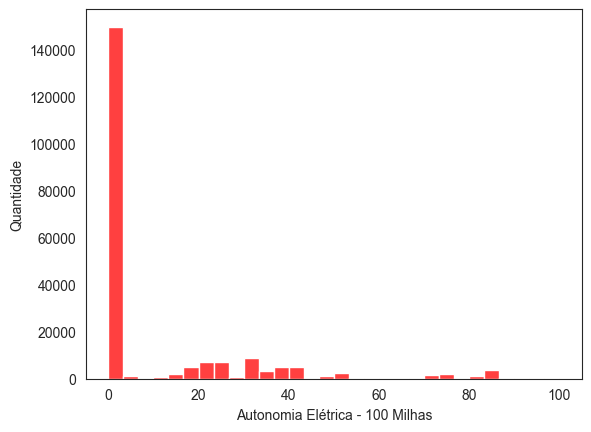

In [33]:
plt.figure()
sns.histplot(df[df['alcance_elétrico']<=100]['alcance_elétrico'],
             bins = 30, kde= False, color = "Red")
plt.xlabel("Autonomia Elétrica - 100 Milhas")
plt.ylabel("Quantidade")
plt.show()

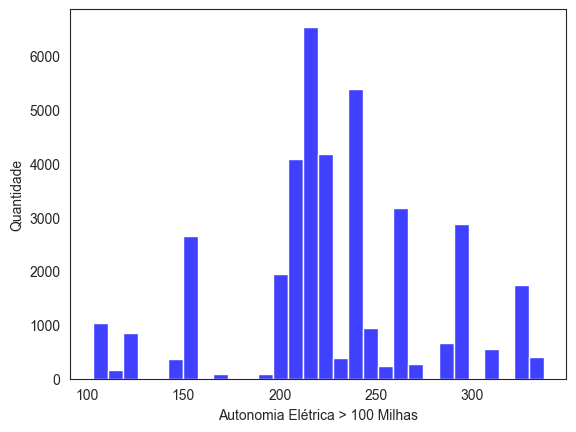

In [34]:
plt.figure()
sns.histplot(df[df['alcance_elétrico']>100]['alcance_elétrico'],
             bins = 30, kde= False, color = "Blue")
plt.xlabel("Autonomia Elétrica > 100 Milhas")
plt.ylabel("Quantidade")
plt.show()

Por fim, ao verificar a autonomia das baterias dos carros e seus preços, foi possível verificar que o carro de maior autonomia, está na faixa de valor de U$60.000,00, enquanto carros com o dobro do valor não possuem autonomia alguma.

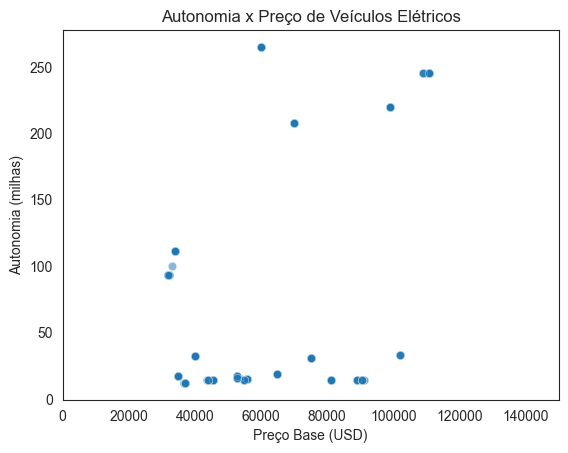

In [37]:
plt.figure()
df_filtrado = df[df['base_msrp'] > 0] #grande numero de linhas com valor zerado
sns.scatterplot(data=df_filtrado, x="base_msrp", y='alcance_elétrico', alpha=0.3)
plt.title("Autonomia x Preço de Veículos Elétricos")
plt.xlabel("Preço Base (USD)")
plt.ylabel("Autonomia (milhas)")
plt.xlim(0, 150000)  # Limita para evitar outliers distorcendo a escala
plt.show()

### ✅ Conclusões

O cenário de carros elétricos no estado de Washington apresenta um crescimento notável na última década. Apesar de algumas lacunas nos dados, foi possível observar que os valores dos veículos, que variam entre US$ 40.000,00 e US$ 140.000,00, não estão diretamente ligados à maior autonomia da bateria.

Um ponto que reforça essa observação é o domínio da Tesla no mercado de vendas do estado, mesmo que a marca não figure entre as três primeiras em termos de autonomia. Isso sugere que, embora o interesse em carros elétricos seja alto e o desejo de reduzir o consumo de combustíveis fósseis esteja presente, a preocupação com a dependência de postos de recarga em longas distâncias ainda não é o fator decisivo para a maioria dos consumidores no momento da compra.